## Kaushal AI EDA

### Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
df = pd.read_csv('data/career_dataset_10k.csv')
df.head()

,user_id,education,experience_years,skills,interests,certification,target_career
0,c8322c2a,MBA,5,"['product management', 'business', 'excel']",['business'],NaN,Product Manager
1,c1349484,BSc,8,"['ui/ux', 'nodejs', 'cybersecurity', 'java']",['web development'],Google Data Analytics,Backend Developer
2,ea49041b,MCA,4,"['seo', 'html']",['marketing'],AWS Certification,Digital Marketer
3,f4240d3e,BTech,3,"['react', 'tableau']",['web development'],Azure Fundamentals,Web Developer
4,34981705,MCA,1,"['nodejs', 'sql', 'excel']",['web development'],Azure Fundamentals,Backend Developer


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   user_id           10000 non-null  str  
 1   education         10000 non-null  str  
 2   experience_years  10000 non-null  int64
 3   skills            10000 non-null  str  
 4   interests         10000 non-null  str  
 5   certification     8333 non-null   str  
 6   target_career     10000 non-null  str  
dtypes: int64(1), str(6)
memory usage: 547.0 KB


In [4]:
df.describe(include='all')

,user_id,education,experience_years,skills,interests,certification,target_career
count,10000,10000,10000.000000,10000,10000,8333,10000
unique,10000,6,NaN,7582,7,5,9
top,c8322c2a,BSc,NaN,"['machine learning', 'data analysis', 'sql', '...",['ai'],AWS Certification,Data Scientist
freq,1,1735,NaN,23,2809,1689,1214
mean,NaN,NaN,5.077500,NaN,NaN,NaN,NaN
std,NaN,NaN,3.167696,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,2.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,8.000000,NaN,NaN,NaN,NaN


In [5]:
# Check for missing values
df.isna().sum()

user_id                0
education              0
experience_years       0
skills                 0
interests              0
certification       1667
target_career          0
dtype: int64

In [6]:
df = df.drop(['user_id'],axis=1)
df.head()

,education,experience_years,skills,interests,certification,target_career
0,MBA,5,"['product management', 'business', 'excel']",['business'],NaN,Product Manager
1,BSc,8,"['ui/ux', 'nodejs', 'cybersecurity', 'java']",['web development'],Google Data Analytics,Backend Developer
2,MCA,4,"['seo', 'html']",['marketing'],AWS Certification,Digital Marketer
3,BTech,3,"['react', 'tableau']",['web development'],Azure Fundamentals,Web Developer
4,MCA,1,"['nodejs', 'sql', 'excel']",['web development'],Azure Fundamentals,Backend Developer


In [7]:
# Classification of columns into cat and num
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int','float']).columns
print(f"Categorical Columns: {cat_cols}")
print(f"Numerical Columns: {num_cols}")

# Unique values in cat columns
for col in cat_cols:
    print(f"{col}: {df[col].unique()[:5]}...")
    print(f"Value Counts: \n{df[col].value_counts()}")
    print("="*50)

Categorical Columns: Index(['education', 'skills', 'interests', 'certification', 'target_career'], dtype='str')
Numerical Columns: Index(['experience_years'], dtype='str')
education: <StringArray>
['MBA', 'BSc', 'MCA', 'BTech', 'Diploma']
Length: 5, dtype: str...
Value Counts: 
education
BSc        1735
BCA        1672
BTech      1666
MCA        1649
Diploma    1649
MBA        1629
Name: count, dtype: int64
skills: <StringArray>
[ '['product management', 'business', 'excel']',
 '['ui/ux', 'nodejs', 'cybersecurity', 'java']',
                              '['seo', 'html']',
                         '['react', 'tableau']',
                   '['nodejs', 'sql', 'excel']']
Length: 5, dtype: str...
Value Counts: 
skills
['machine learning', 'data analysis', 'sql', 'python']                                 23
['networking', 'cybersecurity']                                                        20
['nodejs', 'sql', 'java']                                                              19
['css

In [8]:
# Extract all skills present in dataset
all_skills = set()
for skills in df['skills']:
    for skill in skills.split(','):
        all_skills.add(skill.strip())
print(f"Total Unique Skills: {len(all_skills)}")
print(f"Sample Skills: {list(all_skills)[:10]}")

Total Unique Skills: 98
Sample Skills: ["'tableau']", "['data analysis']", "['tableau'", "['data analysis'", "'cloud computing'", "['content writing']", "'deep learning'", "['figma'", "['css'", "['seo'"]


#### Data Visualization Part 1

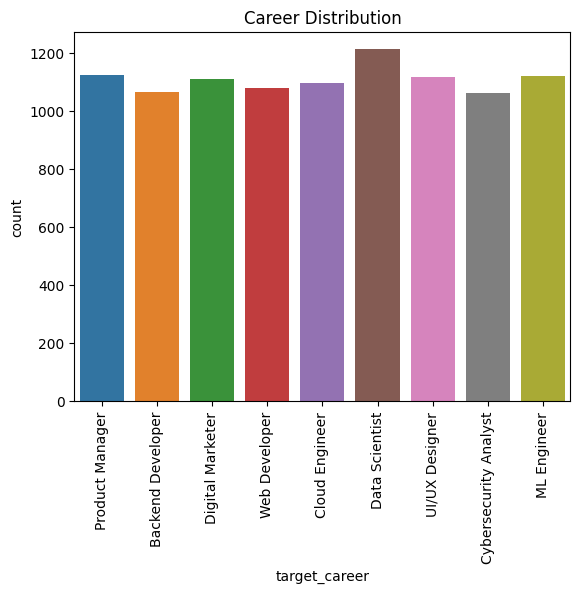

In [9]:
sns.countplot(x='target_career',data=df,hue='target_career')
plt.title("Career Distribution")
plt.xticks(rotation=90)
plt.show()

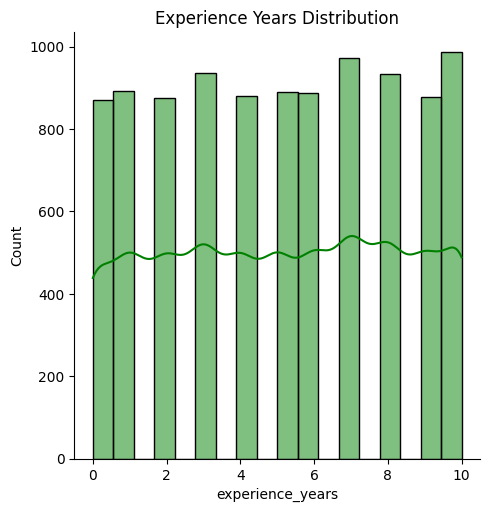

In [10]:
sns.displot(df['experience_years'], kde=True, color='green')
plt.title("Experience Years Distribution")
plt.show()

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'MBA'),
  Text(1, 0, 'BSc'),
  Text(2, 0, 'MCA'),
  Text(3, 0, 'BTech'),
  Text(4, 0, 'Diploma'),
  Text(5, 0, 'BCA')])

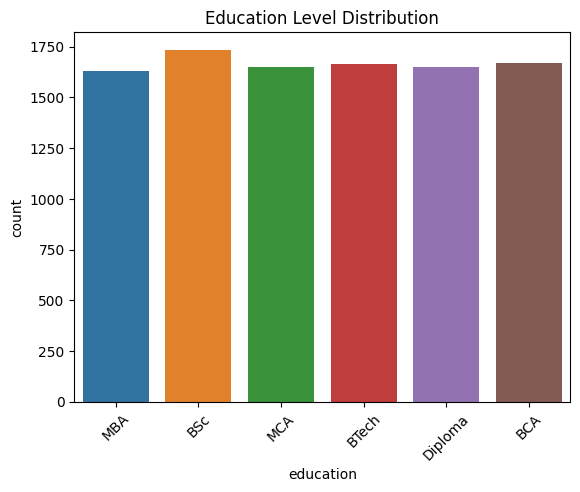

In [11]:
sns.countplot(x='education',data=df, hue='education')
plt.title("Education Level Distribution")
plt.xticks(rotation=45)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Google Data Analytics'),
  Text(1, 0, 'AWS Certification'),
  Text(2, 0, 'Azure Fundamentals'),
  Text(3, 0, 'Coursera ML'),
  Text(4, 0, 'Udemy Web Dev')])

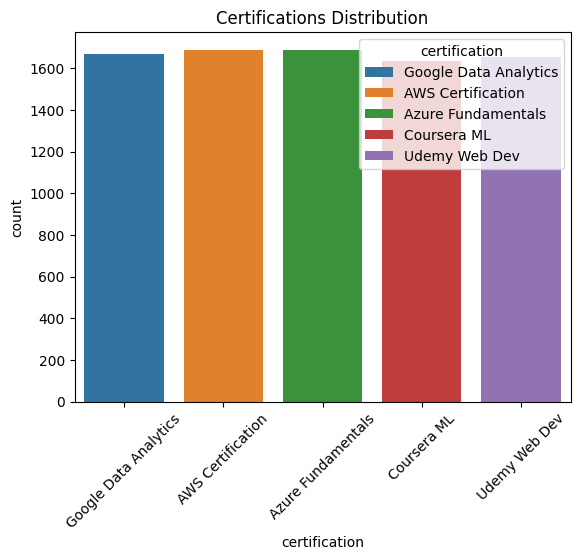

In [12]:
sns.countplot(x='certification',data=df, hue='certification')
plt.title("Certifications Distribution")
plt.xticks(rotation=45)

#### Data Preprocessing

In [13]:
# Fill missing values in certification with 'No Certification'
df['certification'] = df['certification'].fillna('No Certification')
df.isna().sum()

education           0
experience_years    0
skills              0
interests           0
certification       0
target_career       0
dtype: int64

In [14]:
# Remove '[]' from interests and contain only the interests
df['interests'] = df['interests'].str.strip('[]')
df['interests'] = df['interests'].str.replace("'", "")
df.head()

,education,experience_years,skills,interests,certification,target_career
0,MBA,5,"['product management', 'business', 'excel']",business,No Certification,Product Manager
1,BSc,8,"['ui/ux', 'nodejs', 'cybersecurity', 'java']",web development,Google Data Analytics,Backend Developer
2,MCA,4,"['seo', 'html']",marketing,AWS Certification,Digital Marketer
3,BTech,3,"['react', 'tableau']",web development,Azure Fundamentals,Web Developer
4,MCA,1,"['nodejs', 'sql', 'excel']",web development,Azure Fundamentals,Backend Developer


In [15]:
# Converting skills column data into a list of skills
import ast
df['skills'] = df['skills'].apply(ast.literal_eval)
df.head()

,education,experience_years,skills,interests,certification,target_career
0,MBA,5,"[product management, business, excel]",business,No Certification,Product Manager
1,BSc,8,"[ui/ux, nodejs, cybersecurity, java]",web development,Google Data Analytics,Backend Developer
2,MCA,4,"[seo, html]",marketing,AWS Certification,Digital Marketer
3,BTech,3,"[react, tableau]",web development,Azure Fundamentals,Web Developer
4,MCA,1,"[nodejs, sql, excel]",web development,Azure Fundamentals,Backend Developer


In [20]:
print(type(df['skills'].iloc[0]))

<class 'list'>


#### Feature Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MultiLabelBinarizer

In [22]:
# MultiLabelBinarizer for skills
mlb = MultiLabelBinarizer()
df_skills = mlb.fit_transform(df['skills'])
df_skills = pd.DataFrame(df_skills,columns=mlb.classes_)
df = pd.concat([df, df_skills], axis=1)
df = df.drop('skills', axis=1)
df.head()

,education,experience_years,interests,certification,target_career,aws,azure,business,c++,cloud computing,...,networking,nodejs,power bi,product management,python,react,seo,sql,tableau,ui/ux
0,MBA,5,business,No Certification,Product Manager,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
1,BSc,8,web development,Google Data Analytics,Backend Developer,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,MCA,4,marketing,AWS Certification,Digital Marketer,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,BTech,3,web development,Azure Fundamentals,Web Developer,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
4,MCA,1,web development,Azure Fundamentals,Backend Developer,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0


In [23]:
mlb.classes_

array(['aws', 'azure', 'business', 'c++', 'cloud computing',
       'content writing', 'css', 'cybersecurity', 'data analysis',
       'deep learning', 'digital marketing', 'excel', 'figma', 'html',
       'java', 'javascript', 'machine learning', 'networking', 'nodejs',
       'power bi', 'product management', 'python', 'react', 'seo', 'sql',
       'tableau', 'ui/ux'], dtype=object)

In [26]:
# OneHotEncoding for education, interest and certification
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_cols = ohe.fit_transform(df[['education', 'interests', 'certification']])
encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(['education', 'interests', 'certification']))
df = pd.concat([df, encoded_df], axis=1)
df = df.drop(['education', 'interests', 'certification'], axis=1)
df.head()

,experience_years,target_career,aws,azure,business,c++,cloud computing,content writing,css,cybersecurity,...,interests_data,interests_design,interests_marketing,interests_security,interests_web development,certification_Azure Fundamentals,certification_Coursera ML,certification_Google Data Analytics,certification_No Certification,certification_Udemy Web Dev
0,5,Product Manager,0,0,1,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,8,Backend Developer,0,0,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,4,Digital Marketer,0,0,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,Web Developer,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,1,Backend Developer,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   experience_years                     10000 non-null  int64  
 1   target_career                        10000 non-null  str    
 2   aws                                  10000 non-null  int64  
 3   azure                                10000 non-null  int64  
 4   business                             10000 non-null  int64  
 5   c++                                  10000 non-null  int64  
 6   cloud computing                      10000 non-null  int64  
 7   content writing                      10000 non-null  int64  
 8   css                                  10000 non-null  int64  
 9   cybersecurity                        10000 non-null  int64  
 10  data analysis                        10000 non-null  int64  
 11  deep learning                        100

In [28]:
# Label Encoding for target_career
le = LabelEncoder()
df['target_career'] = le.fit_transform(df['target_career'])
df.head()

,experience_years,target_career,aws,azure,business,c++,cloud computing,content writing,css,cybersecurity,...,interests_data,interests_design,interests_marketing,interests_security,interests_web development,certification_Azure Fundamentals,certification_Coursera ML,certification_Google Data Analytics,certification_No Certification,certification_Udemy Web Dev
0,5,6,0,0,1,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,8,0,0,0,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,4,4,0,0,0,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,8,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


#### Feature Engineering

In [2]:
df1 = pd.read_csv('data/career_dataset_10k.csv')
df2 = pd.read_csv('data/cleaned_career_dataset.csv')
print(df1['target_career'].unique())
print(df2['target_career'].unique())

['Product Manager' 'Backend Developer' 'Digital Marketer' 'Web Developer'
 'Cloud Engineer' 'Data Scientist' 'UI/UX Designer'
 'Cybersecurity Analyst' 'ML Engineer']
[6 0 4 8 1 3 7 2 5]


## Exploring 20k dataset

In [27]:
df = pd.read_csv("data/career_dataset_20k.csv")
df.head()

,user_id,education,experience_years,skills,interests,certification,learning_source,projects_count,dominant_project_domain,target_career
0,39a79e1c,BSc,2,"reporting, sql, power bi, google analytics, r,...",machine learning,IBM Data Analyst,university,3,data,Data Analyst
1,5273f7b1,BSc,7,"ci/cd, git, python, kubernetes, prometheus, li...",devops,NaN,self-taught,4,devops,DevOps Engineer
2,d110e626,MCA,1,"statistics, python, tableau, machine learning,...",data engineering,DeepLearning.AI,university,3,data,Data Scientist
3,96b6d0cc,MBA,3,"agile, product management, sql, data analysis,...",business intelligence,NaN,university,3,business,Product Manager
4,e17a4ba5,BSc,3,"excel, statistics, reporting, power bi",data engineering,Tableau Desktop,online-course,5,data,Data Analyst


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19992 entries, 0 to 19991
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   user_id                  19992 non-null  object
 1   education                19992 non-null  object
 2   experience_years         19992 non-null  int64 
 3   skills                   19992 non-null  object
 4   interests                19992 non-null  object
 5   certification            12822 non-null  object
 6   learning_source          19992 non-null  object
 7   projects_count           19992 non-null  int64 
 8   dominant_project_domain  19992 non-null  object
 9   target_career            19992 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.5+ MB


In [4]:
df.isna().sum()

user_id                       0
education                     0
experience_years              0
skills                        0
interests                     0
certification              7170
learning_source               0
projects_count                0
dominant_project_domain       0
target_career                 0
dtype: int64

In [5]:
df['certification'].unique()

array(['IBM Data Analyst', nan, 'DeepLearning.AI', 'Tableau Desktop',
       'AWS DevOps', 'Apple Swift', 'PMP', 'AWS Solutions Architect',
       'Udemy Web Dev', 'Google Cloud Professional',
       'Google Data Analytics', 'Coursera ML', 'AWS ML Specialty',
       'Microsoft Power BI', 'Meta Front-End Developer', 'Meta Marketing',
       'freeCodeCamp', 'Google UX Design', 'Scrum Master',
       'Flutter Certified', 'AWS Security', 'Azure DevOps',
       'Google Associate Android', 'HubSpot Marketing',
       'CompTIA Security+', 'IBM Data Science', 'Coursera Marketing',
       'Oracle Java', 'Coursera PM', 'CEH Ethical Hacking', 'CBAP',
       'Azure Fundamentals', 'Product School PM', 'CISSP',
       'Udemy Mobile Dev', 'Kubernetes CKA',
       'Interaction Design Foundation', 'TensorFlow Developer',
       'MongoDB Associate', 'Google Analytics'], dtype=object)

In [6]:
df['education'].unique()

array(['BSc', 'MCA', 'MBA', 'BTech', 'BCA', 'BBA', 'Diploma'],
      dtype=object)

In [7]:
df['interests'].unique()

array(['machine learning', 'devops', 'data engineering',
       'business intelligence', 'backend development',
       'frontend development', 'product strategy', 'growth marketing',
       'cloud infrastructure', 'mobile development', 'ux research',
       'cybersecurity'], dtype=object)

In [8]:
df['learning_source'].unique()

array(['university', 'self-taught', 'online-course', 'workplace',
       'bootcamp'], dtype=object)

In [11]:
# All unique skills in the dataset
all_skills = set()
for skills in df['skills']:
    for skill in skills.split(','):
        all_skills.add(skill.strip())
print(f"Total Unique Skills: {len(all_skills)}")
print(f"Skills: {list(all_skills)}")

Total Unique Skills: 86
Skills: ['rest apis', 'android', 'networking', 'git', 'firewall', 'nodejs', 'power bi', 'pytorch', 'statistics', 'mongodb', 'business analysis', 'html', 'postgresql', 'redis', 'firebase', 'docker', 'copywriting', 'roadmapping', 'pandas', 'webpack', 'product management', 'google cloud', 'azure', 'seo', 'user research', 'javascript', 'ios', 'deep learning', 'content writing', 'dart', 'python', 'cloud computing', 'process mapping', 'jenkins', 'sql', 'cryptography', 'prometheus', 'java', 'design systems', 'reporting', 'machine learning', 'penetration testing', 'okrs', 'mlflow', 'swift', 'ansible', 'data analysis', 'r', 'requirements gathering', 'wireframing', 'aws', 'cybersecurity', 'siem', 'tensorflow', 'google analytics', 'flutter', 'kubernetes', 'numpy', 'typescript', 'tableau', 'linux', 'sass', 'kotlin', 'terraform', 'microservices', 'ci/cd', 'email marketing', 'next.js', 'react native', 'social media', 'sketch', 'excel', 'agile', 'css', 'react', 'digital market

In [12]:
df.describe(include='all')

,user_id,education,experience_years,skills,interests,certification,learning_source,projects_count,dominant_project_domain,target_career
count,19992,19992,19992.000000,19992,19992,12822,19992,19992.000000,19992,19992
unique,19992,7,NaN,18890,12,39,5,NaN,11,14
top,39a79e1c,BTech,NaN,"requirements gathering, sql, jira",backend development,Meta Front-End Developer,university,NaN,web,Full Stack Developer
freq,1,3272,NaN,5,2787,789,7719,NaN,4063,1477
mean,NaN,NaN,3.455982,NaN,NaN,NaN,NaN,3.840336,NaN,NaN
std,NaN,NaN,2.136637,NaN,NaN,NaN,NaN,2.029130,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN
50%,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN


In [28]:
# Fill missing values in certification with 'No Certification'
df['certification'] = df['certification'].fillna('No Certification')
df.head()

,user_id,education,experience_years,skills,interests,certification,learning_source,projects_count,dominant_project_domain,target_career
0,39a79e1c,BSc,2,"reporting, sql, power bi, google analytics, r,...",machine learning,IBM Data Analyst,university,3,data,Data Analyst
1,5273f7b1,BSc,7,"ci/cd, git, python, kubernetes, prometheus, li...",devops,No Certification,self-taught,4,devops,DevOps Engineer
2,d110e626,MCA,1,"statistics, python, tableau, machine learning,...",data engineering,DeepLearning.AI,university,3,data,Data Scientist
3,96b6d0cc,MBA,3,"agile, product management, sql, data analysis,...",business intelligence,No Certification,university,3,business,Product Manager
4,e17a4ba5,BSc,3,"excel, statistics, reporting, power bi",data engineering,Tableau Desktop,online-course,5,data,Data Analyst


In [14]:
df.isna().sum()

user_id                    0
education                  0
experience_years           0
skills                     0
interests                  0
certification              0
learning_source            0
projects_count             0
dominant_project_domain    0
target_career              0
dtype: int64

In [29]:
# Convert skills column to list of skills
import ast
def parse_skills(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []

    text = str(value).strip()
    if not text:
        return []

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(s).strip() for s in parsed if str(s).strip()]
    except (ValueError, SyntaxError):
        pass

    return [s.strip() for s in text.split(',') if s.strip()]

df['skills'] = df['skills'].apply(parse_skills)
df.head()

,user_id,education,experience_years,skills,interests,certification,learning_source,projects_count,dominant_project_domain,target_career
0,39a79e1c,BSc,2,"[reporting, sql, power bi, google analytics, r...",machine learning,IBM Data Analyst,university,3,data,Data Analyst
1,5273f7b1,BSc,7,"[ci/cd, git, python, kubernetes, prometheus, l...",devops,No Certification,self-taught,4,devops,DevOps Engineer
2,d110e626,MCA,1,"[statistics, python, tableau, machine learning...",data engineering,DeepLearning.AI,university,3,data,Data Scientist
3,96b6d0cc,MBA,3,"[agile, product management, sql, data analysis...",business intelligence,No Certification,university,3,business,Product Manager
4,e17a4ba5,BSc,3,"[excel, statistics, reporting, power bi]",data engineering,Tableau Desktop,online-course,5,data,Data Analyst


### Data Visualization

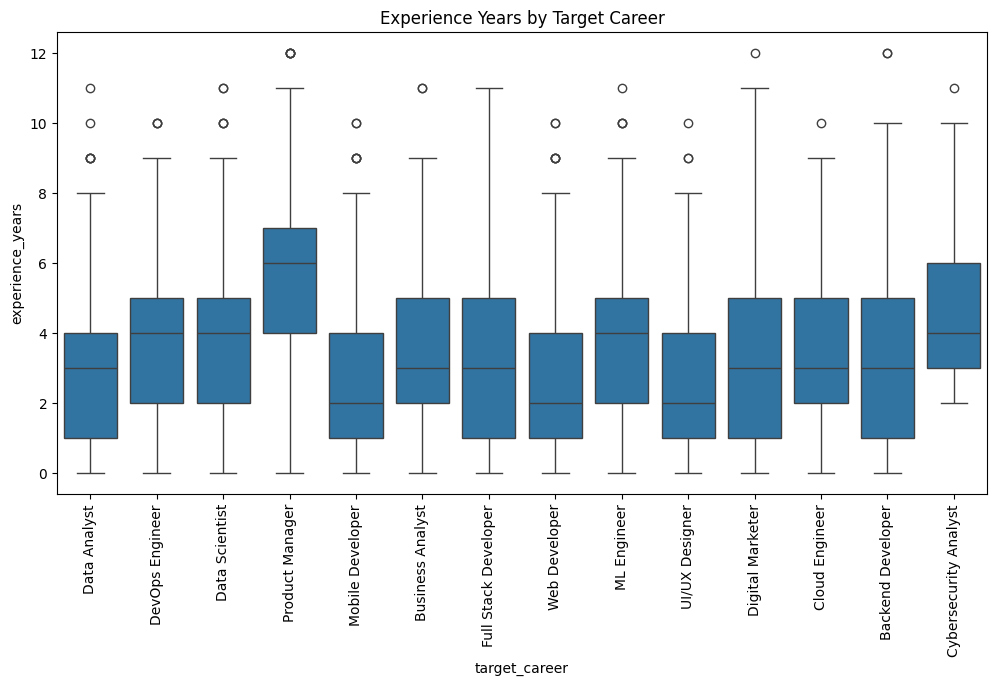

In [17]:
# Subplot of target_career vs experience_years
plt.figure(figsize=(12,6))
sns.boxplot(x='target_career', y='experience_years', data=df)
plt.title("Experience Years by Target Career")
plt.xticks(rotation=90)
plt.show()

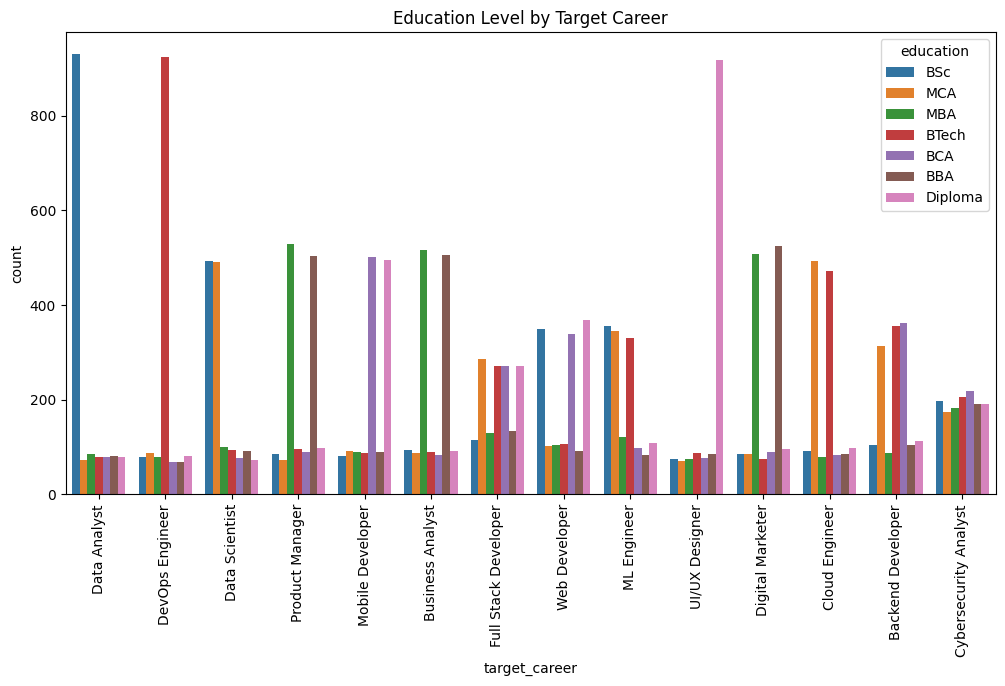

In [18]:
# Countplot of target_career vs education
plt.figure(figsize=(12,6))
sns.countplot(x='target_career', hue='education', data=df)
plt.title("Education Level by Target Career")
plt.xticks(rotation=90)
plt.show()

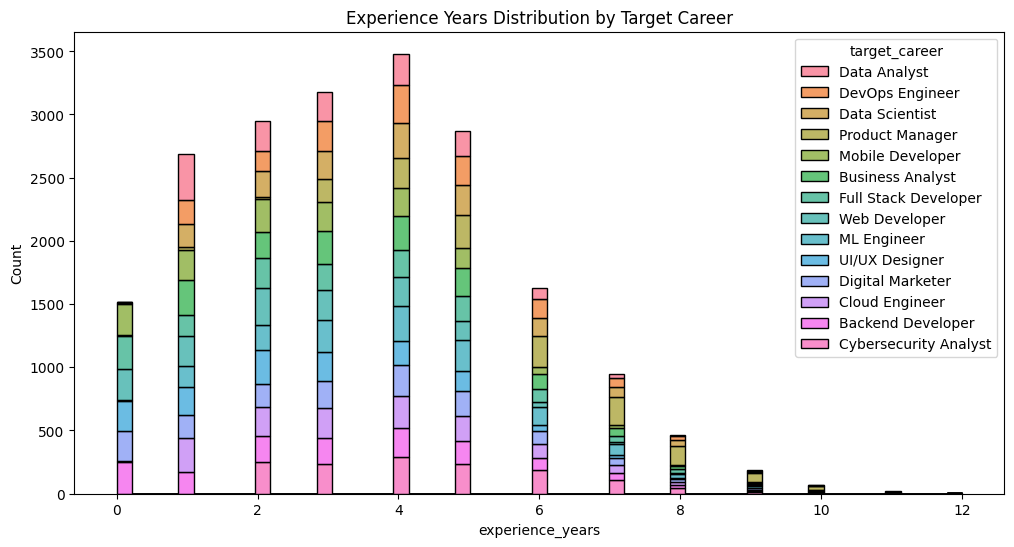

In [19]:
# Distribution of experience_years by target_career
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='experience_years', hue='target_career', multiple='stack')
plt.title("Experience Years Distribution by Target Career")
plt.show()

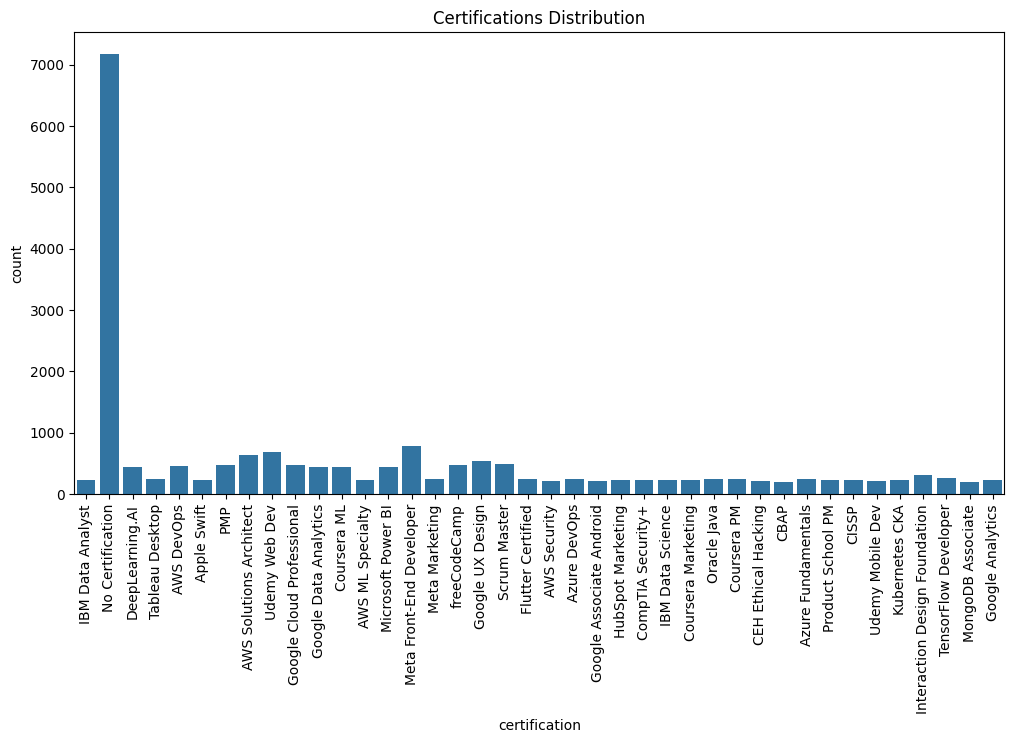

In [22]:
# Countplot of certification
plt.figure(figsize=(12,6))
sns.countplot(x='certification', data=df)
plt.title("Certifications Distribution")
plt.xticks(rotation=90)
plt.show()

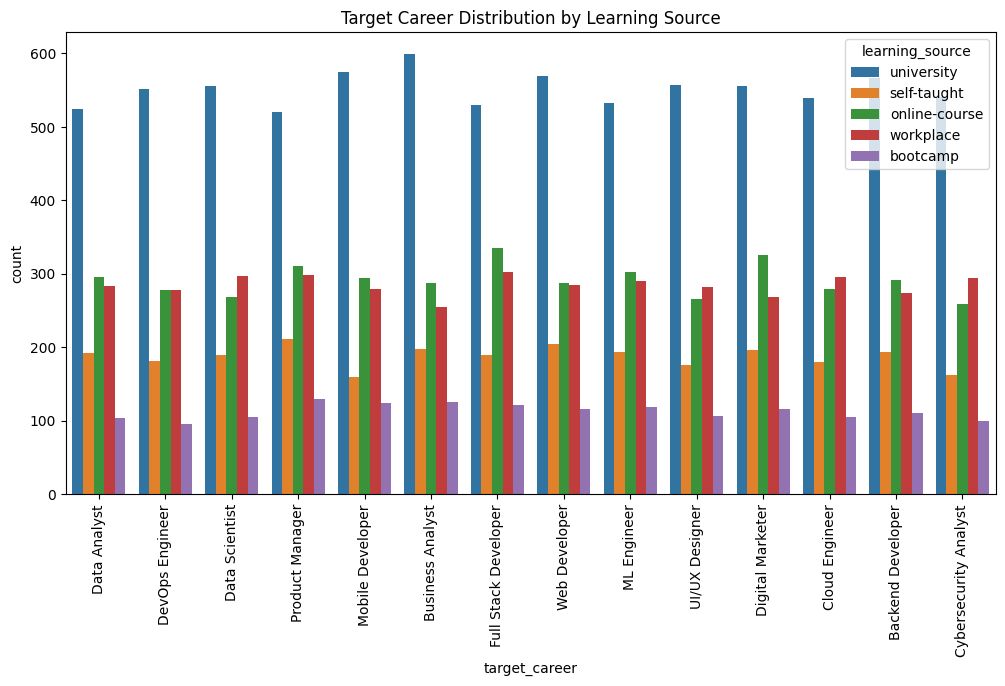

In [25]:
# Countplot of target_career by learning_source
plt.figure(figsize=(12,6))
sns.countplot(x='target_career', hue='learning_source', data=df)
plt.title("Target Career Distribution by Learning Source")
plt.xticks(rotation=90)
plt.show()

### Feature Engineering

In [30]:
# Feature encoding for modeling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MultiLabelBinarizer

le_cols = ['target_career']
ohe_cols = ['education', 'interests', 'certification', 'learning_source', 'dominant_project_domain']
mlb_cols = ['skills']

# MultiLabelBinarizer for skills
mlb = MultiLabelBinarizer()
df_skills = mlb.fit_transform(df['skills'])
df_skills = pd.DataFrame(df_skills, columns=mlb.classes_)
df = pd.concat([df, df_skills], axis=1)
df = df.drop('skills', axis=1)

# OneHotEncoding for education, interest, certification and learning_source
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_cols = ohe.fit_transform(df[ohe_cols])
encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(ohe_cols))
df = pd.concat([df, encoded_df], axis=1)
df = df.drop(ohe_cols, axis=1)

# Label Encoding for target_career
le = LabelEncoder()
df['target_career'] = le.fit_transform(df['target_career'])
df.head()

,user_id,experience_years,projects_count,target_career,adobe xd,ads,agile,android,ansible,aws,...,dominant_project_domain_cloud,dominant_project_domain_data,dominant_project_domain_design,dominant_project_domain_devops,dominant_project_domain_marketing,dominant_project_domain_ml,dominant_project_domain_mobile,dominant_project_domain_none,dominant_project_domain_security,dominant_project_domain_web
0,39a79e1c,2,3,4,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5273f7b1,7,4,6,0,0,0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,d110e626,1,3,5,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,96b6d0cc,3,3,11,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,e17a4ba5,3,5,4,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
# drop user_id
df = df.drop(['user_id'], axis=1)
df.head()

,experience_years,projects_count,target_career,adobe xd,ads,agile,android,ansible,aws,azure,...,dominant_project_domain_cloud,dominant_project_domain_data,dominant_project_domain_design,dominant_project_domain_devops,dominant_project_domain_marketing,dominant_project_domain_ml,dominant_project_domain_mobile,dominant_project_domain_none,dominant_project_domain_security,dominant_project_domain_web
0,2,3,4,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7,4,6,0,0,0,0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,3,5,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,3,11,0,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,5,4,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
# Save the cleaned and encoded dataset and all the encoders for future use
import joblib
df.to_csv("data/cleaned_career_dataset_20k.csv", index=False)
joblib.dump(le, "demo_artifacts/target_career_le_encoder.pkl")
joblib.dump(ohe, "demo_artifacts/ohe_encoder.pkl")
joblib.dump(mlb, "demo_artifacts/mlb_encoder.pkl")

['demo_artifacts/mlb_encoder.pkl']

In [ ]:
# Save the cleaned dataset and all the encoders for future use
import joblib
df.to_csv('data/cleaned_career_dataset.csv', index=False)
joblib.dump(mlb, 'demo_artifacts/skills_mlb.pkl')
joblib.dump(ohe, 'demo_artifacts/edu_interest_cert_ohe.pkl')
joblib.dump(le, 'demo_artifacts/target_career_le.pkl')
print("Data and encoders saved successfully!")